In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from mlxtend.frequent_patterns import apriori, association_rules

In [2]:
movies = pd.read_csv("ml-latest-small/movies.csv")
ratings = pd.read_csv("ml-latest-small/ratings.csv")

print("Movies shape:", movies.shape)
print("Ratings shape:", ratings.shape)

movies.head()

Movies shape: (9742, 3)
Ratings shape: (100836, 4)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [3]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [4]:
unique_users = ratings["userId"].nunique()
unique_movies = ratings["movieId"].nunique()

print("Unique users:", unique_users)
print("Unique movies:", unique_movies)

Unique users: 610
Unique movies: 9724


In [6]:
ratings_filtered = ratings[ratings["rating"] >= 4]

ratings_filtered.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [7]:
data = pd.merge(ratings_filtered, movies, on="movieId")

data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [8]:
data = pd.merge(ratings_filtered, movies, on="movieId")

data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [9]:
user_movie_matrix = data.pivot_table(
    index="userId",
    columns="title",
    values="rating"
)

user_movie_matrix = user_movie_matrix.notnull()

user_movie_matrix.head()

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Salem's Lot (2004),'Til There Was You (1997),"'burbs, The (1989)",(500) Days of Summer (2009),*batteries not included (1987),...And Justice for All (1979),00 Schneider - Jagd auf Nihil Baxter (1994),1-900 (06) (1994),...,Zombieland (2009),Zookeeper (2011),Zoolander (2001),Zootopia (2016),Zulu (1964),[REC] (2007),[REC]² (2009),eXistenZ (1999),xXx (2002),¡Three Amigos! (1986)
userId,,,,,,,,,,,,,,,,,,,,,
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [10]:
frequent_itemsets = apriori(
    user_movie_matrix,
    min_support=0.05,
    use_colnames=True
)

frequent_itemsets.head()

,support,itemsets
0,0.080460,frozenset({12 Angry Men (1957)})
1,0.124795,frozenset({2001: A Space Odyssey (1968)})
2,0.065681,frozenset({28 Days Later (2002)})
3,0.062397,frozenset({300 (2007)})
4,0.057471,"frozenset({40-Year-Old Virgin, The (2005)})"


In [ ]:
supports = [0.1, 0.05, 0.03, 0.01]

for s in supports:
    itemsets = apriori(user_movie_matrix, min_support=s, use_colnames=True)
    print(f"min_support={s} -> {len(itemsets)} frequent itemsets")

min_support=0.1 -> 863 frequent itemsets
min_support=0.05 -> 33189 frequent itemsets


In [11]:
top_itemsets = frequent_itemsets.sort_values(
    by="support",
    ascending=False
)

top_itemsets.head(10)

,support,itemsets
267,0.449918,"frozenset({Shawshank Redemption, The (1994)})"
119,0.408867,frozenset({Forrest Gump (1994)})
244,0.400657,frozenset({Pulp Fiction (1994)})
273,0.369458,"frozenset({Silence of the Lambs, The (1991)})"
206,0.364532,"frozenset({Matrix, The (1999)})"
299,0.330049,frozenset({Star Wars: Episode IV - A New Hope ...
115,0.293924,frozenset({Fight Club (1999)})
260,0.287356,frozenset({Schindler's List (1993)})
2228,0.275862,"frozenset({Shawshank Redemption, The (1994), F..."
300,0.275862,frozenset({Star Wars: Episode V - The Empire S...


In [12]:
rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1
)

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({Fargo (1996)}),frozenset({12 Angry Men (1957)}),0.224959,0.080460,0.050903,0.226277,2.812304,1.0,0.032803,1.188462,0.831465,0.200000,0.158577,0.429465
1,frozenset({12 Angry Men (1957)}),frozenset({Fargo (1996)}),0.080460,0.224959,0.050903,0.632653,2.812304,1.0,0.032803,2.109834,0.700806,0.200000,0.526029,0.429465
2,frozenset({Pulp Fiction (1994)}),frozenset({12 Angry Men (1957)}),0.400657,0.080460,0.052545,0.131148,1.629977,1.0,0.020308,1.058339,0.644863,0.122605,0.055123,0.392104
3,frozenset({12 Angry Men (1957)}),frozenset({Pulp Fiction (1994)}),0.080460,0.400657,0.052545,0.653061,1.629977,1.0,0.020308,1.727519,0.420313,0.122605,0.421135,0.392104
4,frozenset({Schindler's List (1993)}),frozenset({12 Angry Men (1957)}),0.287356,0.080460,0.052545,0.182857,2.272653,1.0,0.029425,1.125311,0.785786,0.166667,0.111357,0.417959


In [13]:
rules_sorted = rules.sort_values(
    by="lift",
    ascending=False
)

rules_sorted[[
    "antecedents",
    "consequents",
    "support",
    "confidence",
    "lift"
]].head(10)

,antecedents,consequents,support,confidence,lift
463808,"frozenset({Kill Bill: Vol. 2 (2004), Matrix, T...","frozenset({Kill Bill: Vol. 1 (2003), Star Wars...",0.052545,0.888889,13.203252
463825,"frozenset({Kill Bill: Vol. 1 (2003), Star Wars...","frozenset({Kill Bill: Vol. 2 (2004), Matrix, T...",0.052545,0.780488,13.203252
463829,"frozenset({Kill Bill: Vol. 2 (2004), Star Wars...","frozenset({Kill Bill: Vol. 1 (2003), Star Wars...",0.052545,0.780488,12.846407
463804,"frozenset({Kill Bill: Vol. 1 (2003), Star Wars...","frozenset({Kill Bill: Vol. 2 (2004), Star Wars...",0.052545,0.864865,12.846407
463793,frozenset({Star Wars: Episode V - The Empire S...,"frozenset({Kill Bill: Vol. 1 (2003), Star Wars...",0.052545,0.864865,12.846407
463840,"frozenset({Kill Bill: Vol. 1 (2003), Star Wars...",frozenset({Star Wars: Episode V - The Empire S...,0.052545,0.780488,12.846407
463792,"frozenset({Kill Bill: Vol. 2 (2004), Matrix, T...","frozenset({Kill Bill: Vol. 1 (2003), Star Wars...",0.052545,0.969697,12.837945
463841,"frozenset({Kill Bill: Vol. 1 (2003), Star Wars...","frozenset({Kill Bill: Vol. 2 (2004), Matrix, T...",0.052545,0.695652,12.837945
463826,"frozenset({Kill Bill: Vol. 1 (2003), Star Wars...","frozenset({Kill Bill: Vol. 2 (2004), Matrix, T...",0.052545,0.800000,12.821053
463809,frozenset({Star Wars: Episode V - The Empire S...,"frozenset({Kill Bill: Vol. 1 (2003), Star Wars...",0.052545,0.800000,12.821053


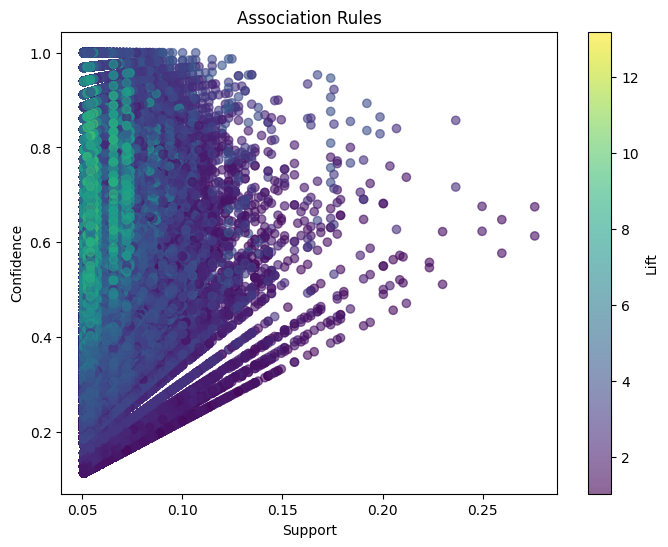

In [14]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    rules["support"],
    rules["confidence"],
    c=rules["lift"],
    cmap="viridis",
    alpha=0.6
)

plt.colorbar(scatter, label="Lift")

plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Association Rules")

plt.show()